In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

In [2]:
# --- load & clean ---
df = pd.read_csv("database.csv")
print(df.head())


        Date          Book Title Time Start  Time End Total Time
0  10/9/2025     Hellbound Heart    9:00 PM   9:30 PM       0:30
1  10/6/2025                blah    7:30 AM   8:00 AM       0:30
2  10/7/2025         Scar Tissue    4:30 PM   5:42 PM       1:11
3  10/8/2025  Catcher in the Rye   12:00 PM  12:15 PM       0:15


In [3]:
# --- normalize "Total Time" from h:mm -> hh:mm:ss ---
tt = df["Total Time"].astype(str).str.strip()
tt = tt.where(tt.str.count(":") == 2, tt + ":00")   # add :00 seconds if missing
df["Total Time (hrs)"] = pd.to_timedelta(tt).dt.total_seconds() / 3600.0

In [4]:
# Ensure Date is a real datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [5]:
# Normalize "Total Time" (e.g., '0:30' -> '0:30:00') and convert to minutes
tt = df["Total Time"].astype(str).str.strip()
tt = tt.where(tt.str.count(":") == 2, tt + ":00")        # add :00 seconds if missing
df["TotalMinutes"] = pd.to_timedelta(tt, errors="coerce").dt.total_seconds() / 60

In [6]:
# Keep only valid rows and sort oldest -> newest
df = df.dropna(subset=["Date", "TotalMinutes"]).sort_values("Date")

In [7]:
# Formatter to show h:mm on the y-axis
def minutes_to_hm(x, _):
    h = int(x) // 60
    m = int(round(x % 60))
    return f"{h}:{m:02d}"

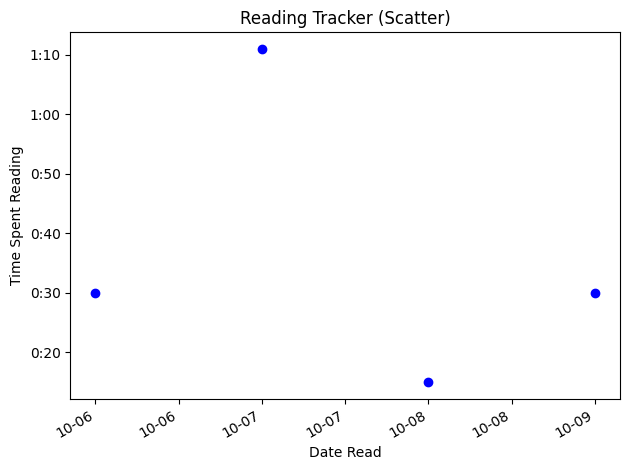

In [11]:
# -------- Scatter (low at bottom, high at top) --------
fig, ax = plt.subplots()
ax.scatter(df["Date"], df["TotalMinutes"], color="blue")
ax.set_xlabel("Date Read")
ax.set_ylabel("Time Spent Reading")
ax.set_title("Reading Tracker (Scatter)")
ax.yaxis.set_major_formatter(FuncFormatter(minutes_to_hm))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


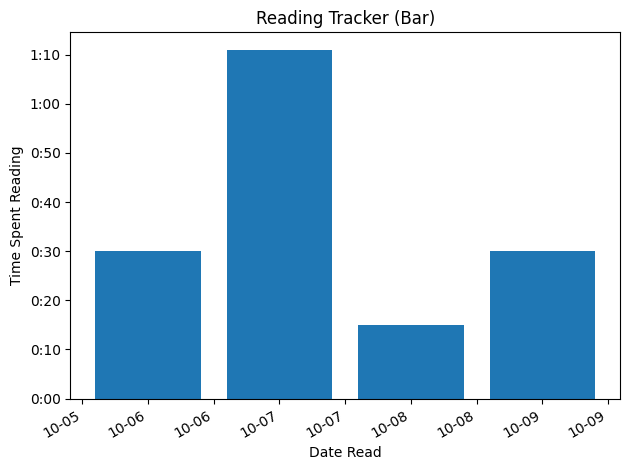

In [12]:
# -------- Bar (old -> new, normal y-axis) --------
fig, ax = plt.subplots()
ax.bar(df["Date"], df["TotalMinutes"], width=pd.Timedelta(days=0.8))
ax.set_xlabel("Date Read")
ax.set_ylabel("Time Spent Reading")
ax.set_title("Reading Tracker (Bar)")
ax.yaxis.set_major_formatter(FuncFormatter(minutes_to_hm))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()